Epoch 0 Loss 0.4743812680244446
Epoch 500 Loss 1.4298313544713892e-05
Epoch 1000 Loss 5.093328127259156e-06
Epoch 1500 Loss 2.2080128019297263e-06
Epoch 2000 Loss 1.5579696537315613e-06
Epoch 2500 Loss 2.0396653326315572e-06
MSE: 9.213833973946133e-05


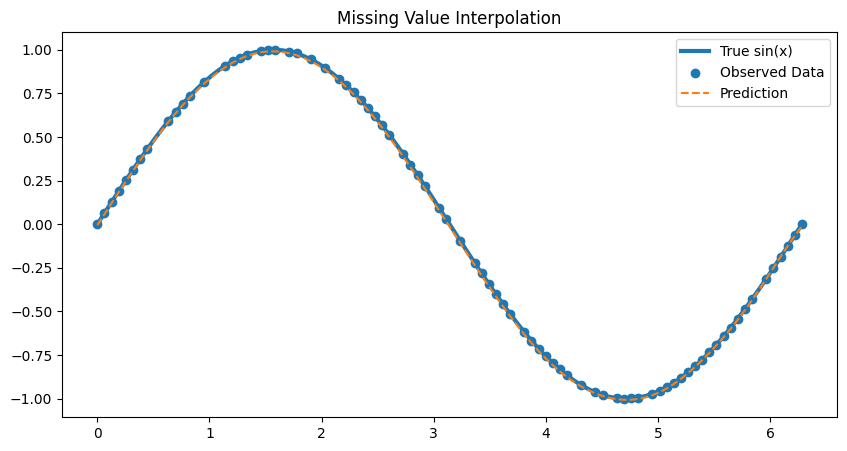

In [ ]:
#欠損値予測２次元グラフ 普通NNver（Neural ODE無し）

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================
# データ生成
# ============================================

x = np.linspace(0, 2*np.pi, 100)

y_true = np.sin(x)

# ============================================
# 欠損作成（null）
# ============================================

y_missing = y_true.copy()

# ランダムに20個欠損
missing_idx = np.random.choice(100, 20, replace=False)

y_missing[missing_idx] = np.nan

# mask作成
mask = ~np.isnan(y_missing)

# ============================================
# Tensor化
# ============================================

x_tensor = torch.tensor(x, dtype=torch.float32).view(-1,1)

y_tensor = torch.tensor(
    np.nan_to_num(y_missing, nan=0.0),
    dtype=torch.float32
).view(-1,1)

mask_tensor = torch.tensor(mask)

# ============================================
# 簡単なNN
# ============================================

model = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),

    nn.Linear(64,64),
    nn.Tanh(),

    nn.Linear(64,1)
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(x_tensor)

    # 欠損していない部分だけloss
    loss = criterion(
        pred[mask_tensor],
        y_tensor[mask_tensor]
    )

    loss.backward()

    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} Loss {loss.item()}")

# ============================================
# 推論
# ============================================

with torch.no_grad():
    y_pred = model(x_tensor).numpy()

# ============================================
# MSE計算
# ============================================

mse = np.mean((y_true - y_pred.flatten())**2)

print("MSE:", mse)

# ============================================
# 可視化
# ============================================

plt.figure(figsize=(10,5))

# 真値
plt.plot(x, y_true,
         label='True sin(x)',
         linewidth=3)

# 欠損データ
plt.scatter(
    x[mask],
    y_missing[mask],
    label='Observed Data'
)

# 予測
plt.plot(
    x,
    y_pred,
    '--',
    label='Prediction'
)

plt.legend()

plt.title("Missing Value Interpolation")

plt.show()

Epoch 0
Loss: 15.117744445800781
Epoch 50
Loss: 0.021870993077754974
Epoch 100
Loss: 0.0013069520937278867
Epoch 150
Loss: 0.0009677678463049233
MSE: 0.0008449328123614533

===== 欠損点予測結果 =====

欠損点 index=5
x = 1.0833
真値       : 0.883512
予測値     : 0.898493
絶対誤差   : 0.014981
--------------------------
欠損点 index=10
x = 2.1666
真値       : 0.827689
予測値     : 0.820795
絶対誤差   : 0.006894
--------------------------
欠損点 index=15
x = 3.2499
真値       : -0.108119
予測値     : -0.081955
絶対誤差   : 0.026164
--------------------------
欠損点 index=20
x = 4.3332
真値       : -0.928977
予測値     : -0.953802
絶対誤差   : 0.024825
--------------------------
欠損点 index=25
x = 5.4165
真値       : -0.762162
予測値     : -0.707654
絶対誤差   : 0.054508
--------------------------

欠損点MSE : 0.00090877



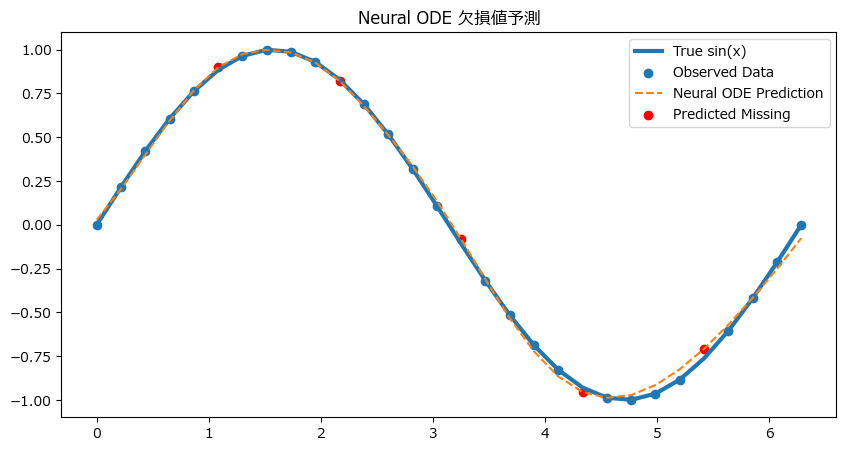

In [ ]:
#欠損値予測２次元グラフ Neural ODEver

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
# 日本語フォントを指定
matplotlib.rcParams['font.family'] = 'Meiryo'
import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# データ生成
# ============================================

x = np.linspace(0, 2*np.pi, 30)

y_true = np.sin(x)

# ============================================
# 欠損作成
# ============================================

y_missing = y_true.copy()

#欠損値作成（ランダム版）
#missing_idx = np.random.choice(100, 20, replace=False)

#欠損値作成（指定版）。中身の数字は配列の番号（インデックス）。

missing_idx = [
    5,
    # 6,
    # 7,
    # 8,
    # 9,
    10,
    15,
    20,
    25


]


y_missing[missing_idx] = np.nan

mask = ~np.isnan(y_missing)

# ============================================
# Tensor化
# ============================================

x_tensor = torch.tensor(
    x,
    dtype=torch.float32
).view(-1,1)

y_tensor = torch.tensor(
    np.nan_to_num(y_missing, nan=0.0),
    dtype=torch.float32
).view(-1,1)

mask_tensor = torch.tensor(mask)

# ============================================
# ODE Function
# dh/dt = f(h,t)
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,1)
        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE Model
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.odefunc = ODEFunc()

    def forward(self, x_input):

        # 初期値
        h0 = x_input

        # ODE時間
        t = torch.tensor([0,1]).float()

        # ODE solve
        out = odeint(
            self.odefunc,
            h0,
            t,
            #method='rk4'
            method='euler'
        )

        # 最終時刻
        return out[-1]

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# ============================================
# 学習
# ============================================

epochs = 200

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(x_tensor)

    loss = criterion(
        pred[mask_tensor],
        y_tensor[mask_tensor]
    )

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}")
        print("Loss:", loss.item())

# ============================================
# 推論
# ============================================

with torch.no_grad():

    y_pred = model(x_tensor).numpy()

# ============================================
# MSE
# ============================================

mse = np.mean(
    (y_true - y_pred.flatten())**2
)

print("MSE:", mse)

# ============================================
# 欠損点予測結果
# ============================================

print("\n===== 欠損点予測結果 =====\n")

for idx in missing_idx:

    x_val = x[idx]

    true_val = y_true[idx]

    pred_val = y_pred[idx][0]

    error = abs(pred_val - true_val)

    print(f"欠損点 index={idx}")

    print(
        f"x = {x_val:.4f}"
    )

    print(
        f"真値       : {true_val:.6f}"
    )

    print(
        f"予測値     : {pred_val:.6f}"
    )

    print(
        f"絶対誤差   : {error:.6f}"
    )

    print("--------------------------")

# ============================================
# 欠損点MSE
# ============================================

missing_true = y_true[missing_idx]

missing_pred = y_pred.flatten()[missing_idx]

missing_mse = np.mean(
    (missing_true - missing_pred)**2
)

print("\n===================================")

print(
    f"欠損点MSE : {missing_mse:.8f}"
)

print("===================================\n")

# ============================================
# 可視化
# ============================================

plt.figure(figsize=(10,5))

# 真値
plt.plot(
    x,
    y_true,
    label='True sin(x)',
    linewidth=3
)

# 観測点
plt.scatter(
    x[mask],
    y_missing[mask],
    label='Observed Data'
)

# 予測
plt.plot(
    x,
    y_pred,
    '--',
    label='Neural ODE Prediction'
)

# 欠損位置
plt.scatter(
    x[missing_idx],
    y_pred[missing_idx],
    color='red',
    label='Predicted Missing'
)

plt.legend()

plt.title("Neural ODE 欠損値予測")

plt.show()

Epoch 0 Loss 12.938637733459473
Epoch 50 Loss 2.197392702102661
Epoch 100 Loss 0.08700335025787354
Epoch 150 Loss 0.011763271875679493
MSE: 0.0060122885738451036
===== 欠損点予測結果 =====

欠損点 1
予測結果 : (x,y,z)=(-1.31, -1.31, 3.4852)
真値 : (x,y,z)=(-1.31, -1.31, 3.4340)
絶対誤差 : 0.051242
--------------------------
欠損点 2
予測結果 : (x,y,z)=(0.76, -1.31, 2.2665)
真値 : (x,y,z)=(0.76, -1.31, 2.2925)
絶対誤差 : 0.025994
--------------------------
欠損点 3
予測結果 : (x,y,z)=(-0.34, -0.90, 0.9116)
真値 : (x,y,z)=(-0.34, -0.90, 0.9227)
絶対誤差 : 0.011127
--------------------------
欠損点 4
予測結果 : (x,y,z)=(-0.62, -0.62, 0.6434)
真値 : (x,y,z)=(-0.62, -0.62, 0.7705)
絶対誤差 : 0.127101
--------------------------
欠損点 5
予測結果 : (x,y,z)=(1.45, -0.62, 2.4951)
真値 : (x,y,z)=(1.45, -0.62, 2.4828)
絶対誤差 : 0.012383
--------------------------
欠損点 6
予測結果 : (x,y,z)=(-0.90, -0.34, 0.8940)
真値 : (x,y,z)=(-0.90, -0.34, 0.9227)
絶対誤差 : 0.028691
--------------------------
欠損点 7
予測結果 : (x,y,z)=(0.07, 0.07, 0.0937)
真値 : (x,y,z)=(0.07, 0.07, 0.0095)
絶対誤差 : 

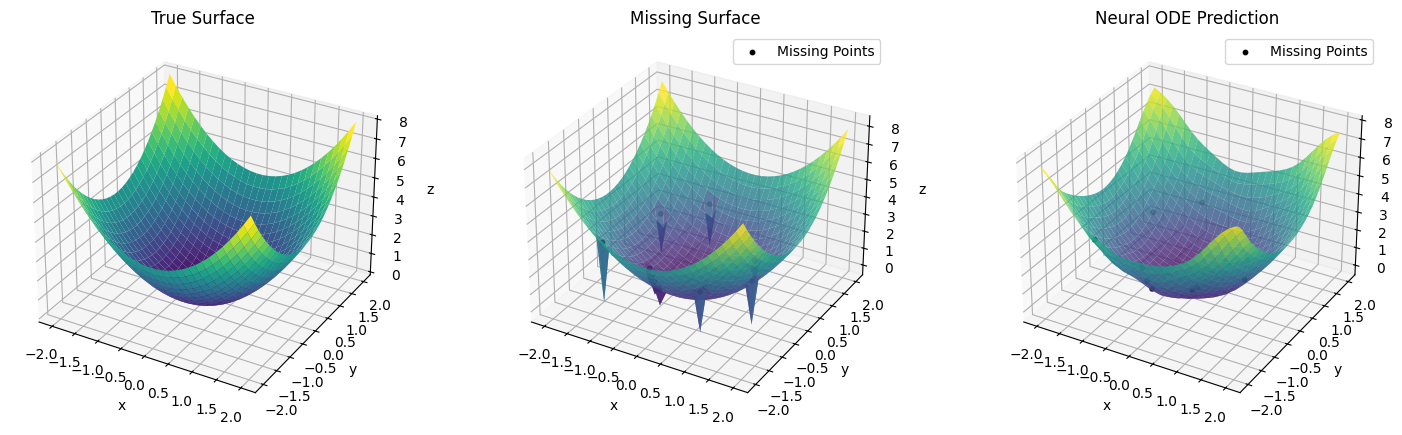

In [17]:
#3次元曲面（z=x^2+y^2）回帰（neural ode ver）

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# データ生成
# z = x^2 + y^2
# ============================================

grid_size = 30

x = np.linspace(-2, 2, grid_size)
y = np.linspace(-2, 2, grid_size)

X, Y = np.meshgrid(x, y)#x座標とy座標の組み合わせを作るもの。計算やプロットで必要

Z = X**2 + Y**2
#Z= np.sin(2*X) * np.cos(2*Y)

# ============================================
# 欠損値作成
# ============================================

"""
#欠損値ランダム版--------------------------------
Z_missing = Z.copy()

# ランダム欠損
missing_ratio = 0.3

mask = np.random.rand(*Z.shape) > missing_ratio

Z_missing[~mask] = np.nan #欠損値（nan）を代入
#-----------------------------------------------
"""

#欠損値座標指定版--------------------------------
mask = np.ones(Z.shape, dtype=bool)

# 欠損させたい座標(index)
missing_points = [

  
    (5,5),#この数字は“(x配列のインデックス,y配列のインデックス)”
    (10,10),
    (15,15),
    (20,20),

    (5,20),
    (20,5),

    (8,12),
    (12,8),

    (25,10),
    (10,25)

    # (20,23),#この数字は“(x配列のインデックス,y配列のインデックス)”
    # (20,24),

    # (6,8),
    # (6,9),
    # (7,8),
    # (7,9),

    # (26,0),
    # (26,1),
    # (27,0),
    # (27,1)
]

# 指定点を欠損化
for i,j in missing_points:

    mask[i,j] = False

# 欠損入りデータ
Z_missing = Z.copy()

Z_missing[~mask] = np.nan


# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()], #「データ生成」で作ったmeshgridのデータを一列の座標データのペアを作る（平坦化）
    axis=1
)

targets = Z.flatten()

mask_flat = mask.flatten() #元々の2次元の mask（True=データあり、False=欠損）を、上のリストと同じ順番で1列にします。中身は [True, False, True, ...] のようなチェックリストになる

# 観測点だけ使用
#coords_train: モデルの入力（場所）となる、実測データがある地点だけの座標リスト。
#targets_train: モデルの正解（ラベル）となる、実測データがある地点だけの値リスト。
coords_train = coords[mask_flat]#mask_flatがTrue、つまり「データあり（観測点）」のxy座標だけ抜き出す
targets_train = targets[mask_flat]#同じく欠損値ではないzの値だけ抜き出す

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,64),#x座標とy座標の二つを入力
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE Model
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc() #上のODE Functionへ飛んで計算

        # 最終出力
        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        # 初期状態
        h0 = x_input

        # 時間
        t = torch.tensor([0,1]).float() #今回はt(時間)が０～１の間で学習

        # ODE solve
        out = odeint(
            self.odefunc,
            h0,
            t,
            method='euler'#オイラー法
            #method='rk4'#ルンクゲッタ法
        )

        # 最終状態
        h_final = out[-1] #out(出力リスト)の[-1]（一番最後を意味するpythonのインデックス指定）を取り出す

        # z予測
        z_pred = self.output_layer(h_final)

        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01 #学習率
)

# ============================================
# 学習
# ============================================

epochs = 200

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)
    
    #誤差計算。criterion＝「基準」の意味。損失関数のことを指す。pred：予測値、targets_tensor：正解データ
    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全点予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

#torch.no_grad(): 「今は学習ではなく推論（予測）中なので、重みを更新するためのデータ（勾配）は記録しなくていいよ」という指定です。これによりメモリの節約と計算の高速化ができます。
#model(...): モデルに全座標を一気に流し込み、各点の予測値（例えばその地点の高さやクラス確率など）を計算します。
#.numpy(): PyTorchのテンソルを、扱いやすいNumPy配列に戻しています。

with torch.no_grad():

    Z_pred = model(
        all_coords_tensor
    ).numpy()


#モデルに入れるために flatten() で 「1次元の長い列」 になっていた予測結果を、再び 「縦×横（grid_size × grid_size）の行列」 に並べ直しています。
#これにより、2次元グラフの X や Y と形が揃い、描画できるようになる
Z_pred = Z_pred.reshape(
    grid_size,
    grid_size
)

# ============================================
# MSE
# ============================================

mse = np.mean((Z - Z_pred)**2)

print("MSE:", mse)

# 欠損点座標===================================
missing_x = X[~mask]
missing_y = Y[~mask]

# 真値側の欠損点高さ
missing_z= Z[~mask]

# 予測側の欠損点高さ
missing_z_pred = Z_pred[~mask]


# ============================================
# 欠損点精度表示
# ============================================

print("===== 欠損点予測結果 =====\n")

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = missing_z_pred[idx]
    true_val = missing_z[idx]

    error = abs(pred_val - true_val)

    print(f"欠損点 {idx+1}")

    print(
        f"予測結果 : "
        f"(x,y,z)=("
        f"{x_val:.2f}, "
        f"{y_val:.2f}, "
        f"{pred_val:.4f})"
    )

    print(
        f"真値 : "
        f"(x,y,z)=("
        f"{x_val:.2f}, "
        f"{y_val:.2f}, "
        f"{true_val:.4f})"
    )

    print(
        f"絶対誤差 : {error:.6f}"
    )

    print("--------------------------")

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(
    (missing_z - missing_z_pred)**2
)

print("\n===================================")
print("欠損点MSE :", missing_mse)
print("===================================\n")


# ============================================
# 可視化
# ============================================

fig = plt.figure(figsize=(18,5))

# 真値
ax1 = fig.add_subplot(131, projection='3d')

ax1.plot_surface(
    X, Y, Z,
    cmap='viridis'
)
"""
# 欠損点を赤表示
ax1.scatter(
    missing_x,
    missing_y,
    missing_z,
    color='black',
    s=10,
    label='Missing Points'
)
ax1.legend()
"""

ax1.set_title("True Surface")
ax1.set_xlabel('x') # x軸のラベル
ax1.set_ylabel('y') # y軸のラベル
ax1.set_zlabel('z') # z軸のラベル

# 欠損あり
ax2 = fig.add_subplot(132, projection='3d')

ax2.plot_surface(
    X,
    Y,
    np.nan_to_num(Z_missing, nan=0),
    cmap='viridis', #cmap(color map):色の付け方の指定,viridis は matplotlib 標準のカラーマップです。
    alpha=0.8 #透明度
)

#欠損点を赤色で表示------


ax2.scatter(
    missing_x,
    missing_y,
    missing_z,
    color='black',
    s=10,
    label='Missing Points'
)

ax2.legend()
ax2.set_title("Missing Surface")
ax2.set_xlabel('x') # x軸のラベル
ax2.set_ylabel('y') # y軸のラベル
ax2.set_zlabel('z') # z軸のラベル

# 予測
ax3 = fig.add_subplot(133, projection='3d')

ax3.plot_surface(
    X,
    Y,
    Z_pred,
    cmap='viridis',
    alpha=0.8 #透明度
)
# 欠損点を赤表示
ax3.scatter(
    missing_x,
    missing_y,
    missing_z,
    color='black',
    s=10,
    label='Missing Points'
)

ax3.legend()

ax3.legend()
ax3.set_title("Neural ODE Prediction")
ax3.set_xlabel('x') # x軸のラベル
ax3.set_ylabel('y') # y軸のラベル
ax3.set_zlabel('z') # z軸のラベル

plt.show()
import plotly.graph_objects as go
# 真の関数グラフ
true_fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale='Greens',
            contours = {
            "x": {"show": True},
            "y": {"show": True}
        }
      )
    ]
)
true_fig.update_layout(
    title='True Surface', # タイトルのテキスト
    title_x=0.5,               # タイトルを中央に配置（0が左、1が右）
    scene=dict(
        aspectmode='cube' #xyz軸の長さを均等に
    )
)
true_fig.show()


# neural ode予測結果
pred_fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z_pred,
            colorscale='Greens',
            contours = {
            "x": {"show": True},
            "y": {"show": True}
        }
      )
    ]
)
# 欠損点を赤表示
pred_fig.add_trace(
    go.Scatter3d(
        x=missing_x,
        y=missing_y,
        z=missing_z,

        mode='markers',

        marker=dict(
            size=1,
            color='black'
        ),

        name='Missing Points'
    )
)

pred_fig.update_layout(
    title='Neural ODE Prediction', # タイトルのテキスト
    title_x=0.5,               # タイトルを中央に配置（0が左、1が右）
    scene=dict(
        aspectmode='cube' #xyz軸の長さを均等に
    )
)

pred_fig.show()

In [3]:
#値範囲変換
def value_conversion(x):
    new_val=((x-minA)*(maxB-minB)/(maxA-minA))+minB
    return new_val


In [5]:
minA=-1
maxA=1
minB=0
maxB=255
x=0.4352
value_conversion(x)

182.988

Epoch 0 Loss 167064400.0
Epoch 50 Loss 165453104.0
Epoch 100 Loss 160299616.0
Epoch 150 Loss 151916416.0
Epoch 200 Loss 140795696.0
Epoch 250 Loss 127751960.0
Epoch 300 Loss 113761920.0
Epoch 350 Loss 99836512.0
Epoch 400 Loss 86898712.0
Epoch 450 Loss 75673128.0
Epoch 500 Loss 66601592.0
Epoch 550 Loss 59805436.0
Epoch 600 Loss 55110408.0
Epoch 650 Loss 52133416.0
Epoch 700 Loss 50405544.0
Epoch 750 Loss 49487352.0
Epoch 800 Loss 49039036.0
Epoch 850 Loss 48836552.0
Epoch 900 Loss 48751024.0
Epoch 950 Loss 48716544.0
Epoch 1000 Loss 48702680.0
Epoch 1050 Loss 48696544.0
Epoch 1100 Loss 97029256.0
Epoch 1150 Loss 61179824.0
Epoch 1200 Loss 47786324.0
Epoch 1250 Loss 36346276.0
Epoch 1300 Loss 18227968.0
Epoch 1350 Loss 12094855.0
Epoch 1400 Loss 9264538.0
Epoch 1450 Loss 7429645.5
Epoch 1500 Loss 6136036.5
Epoch 1550 Loss 5130305.5
Epoch 1600 Loss 4422676.5
Epoch 1650 Loss 3633170.5
Epoch 1700 Loss 3196005.5
Epoch 1750 Loss 2748216.5
Epoch 1800 Loss 2518374.5
Epoch 1850 Loss 2551749.25

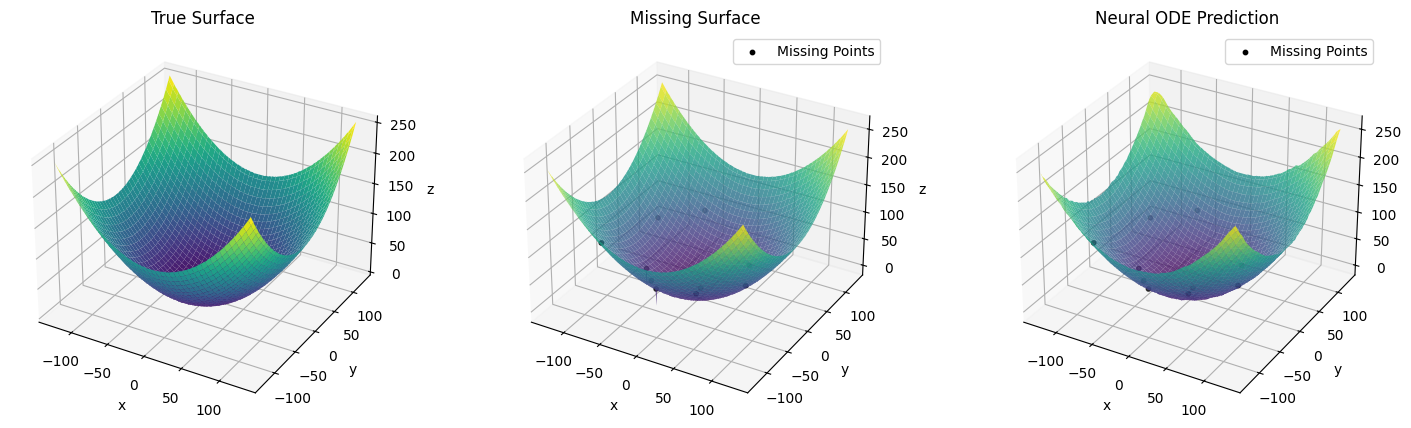

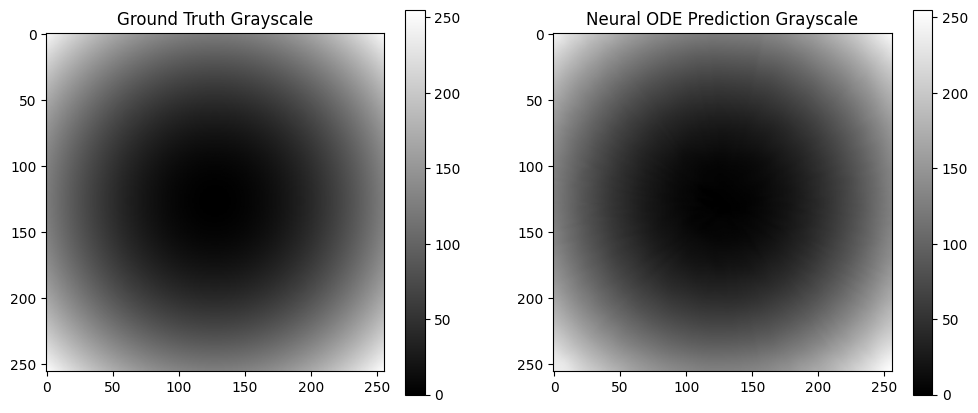

In [2]:
#3次元曲面補間 グレースケール表示

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# データ生成
# z = x^2 + y^2
# ============================================
"""
grid_size = 30

x = np.linspace(-2, 2, grid_size)
y = np.linspace(-2, 2, grid_size)
"""
grid_size = 256

x = np.linspace(-127, 128, grid_size)
y = np.linspace(-127, 128, grid_size)


X, Y = np.meshgrid(x, y)#x座標とy座標の組み合わせを作るもの。計算やプロットで必要

Z = X**2 + Y**2
#Z= np.sin(2*X) * np.cos(2*Y)



# ============================================
# 欠損値作成
# ============================================



#欠損値座標指定版--------------------------------
mask = np.ones(Z.shape, dtype=bool)

# 欠損させたい座標(index)
missing_points = [

  
    (43,43),
    (85,85),
    (128,128),
    (171,171),

    (43,171),
    (171,43),

    (68,102),
    (102,68),

    (213,85),
    (85,213)

    # (20,23),#この数字は“(x配列のインデックス,y配列のインデックス)”
    # (20,24),

    # (6,8),
    # (6,9),
    # (7,8),
    # (7,9),

    # (26,0),
    # (26,1),
    # (27,0),
    # (27,1)
]

# 指定点を欠損化
for i,j in missing_points:

    mask[i,j] = False

# 欠損入りデータ
Z_missing = Z.copy()

Z_missing[~mask] = np.nan


# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()], #「データ生成」で作ったmeshgridのデータを一列の座標データのペアを作る（平坦化）
    axis=1
)

targets = Z.flatten()

mask_flat = mask.flatten() #元々の2次元の mask（True=データあり、False=欠損）を、上のリストと同じ順番で1列にします。中身は [True, False, True, ...] のようなチェックリストになる

# 観測点だけ使用
#coords_train: モデルの入力（場所）となる、実測データがある地点だけの座標リスト。
#targets_train: モデルの正解（ラベル）となる、実測データがある地点だけの値リスト。
coords_train = coords[mask_flat]#mask_flatがTrue、つまり「データあり（観測点）」のxy座標だけ抜き出す
targets_train = targets[mask_flat]#同じく欠損値ではないzの値だけ抜き出す

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,64),#x座標とy座標の二つを入力
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE Model
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc() #上のODE Functionへ飛んで計算

        # 最終出力
        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        # 初期状態
        h0 = x_input

        # 時間
        t = torch.tensor([0,1]).float() #今回はt(時間)が０～１の間で学習

        # ODE solve
        out = odeint(
            self.odefunc,
            h0,
            t,
            method='euler'#オイラー法
            #method='rk4'#ルンクゲッタ法
        )

        # 最終状態
        h_final = out[-1] #out(出力リスト)の[-1]（一番最後を意味するpythonのインデックス指定）を取り出す

        # z予測
        z_pred = self.output_layer(h_final)

       


        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01 #学習率
)

# ============================================
# 学習
# ============================================

epochs = 10000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)
    
    #誤差計算。criterion＝「基準」の意味。損失関数のことを指す。pred：予測値、targets_tensor：正解データ
    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全点予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

#torch.no_grad(): 「今は学習ではなく推論（予測）中なので、重みを更新するためのデータ（勾配）は記録しなくていいよ」という指定です。これによりメモリの節約と計算の高速化ができます。
#model(...): モデルに全座標を一気に流し込み、各点の予測値（例えばその地点の高さやクラス確率など）を計算します。
#.numpy(): PyTorchのテンソルを、扱いやすいNumPy配列に戻しています。

with torch.no_grad():

    Z_pred = model(
        all_coords_tensor
    ).numpy()


#モデルに入れるために flatten() で 「1次元の長い列」 になっていた予測結果を、再び 「縦×横（grid_size × grid_size）の行列」 に並べ直しています。
#これにより、2次元グラフの X や Y と形が揃い、描画できるようになる
Z_pred = Z_pred.reshape(
    grid_size,
    grid_size
)
# ============================================
# 0~255へ変換（グレースケール化）
# ============================================
"""
# 最小値・最大値
z_min = Z_pred.min()
z_max = Z_pred.max()

# 0~255へ正規化
Z_pred_gray = (
    (Z_pred - z_min)
    / (z_max - z_min)
    * 255
)

# uint8へ変換（画像用）
Z_pred_gray = Z_pred_gray.astype(np.uint8)
"""
# ============================================
# MSE
# ============================================

mse = np.mean((Z - Z_pred)**2)

print("MSE:", mse)

# 欠損点座標===================================
missing_x = X[~mask]
missing_y = Y[~mask]

# 真値側の欠損点高さ
missing_z= Z[~mask]

# 予測側の欠損点高さ
missing_z_pred = Z_pred[~mask]


# ============================================
# 欠損点精度表示
# ============================================

print("===== 欠損点予測結果 =====\n")

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = missing_z_pred[idx]
    true_val = missing_z[idx]

    error = abs(pred_val - true_val)

    print(f"欠損点 {idx+1}")

    print(
        f"予測結果 : "
        f"(x,y,z)=("
        f"{x_val:.2f}, "
        f"{y_val:.2f}, "
        f"{pred_val:.4f})"
    )

    print(
        f"真値 : "
        f"(x,y,z)=("
        f"{x_val:.2f}, "
        f"{y_val:.2f}, "
        f"{true_val:.4f})"
    )

    print(
        f"絶対誤差 : {error:.6f}"
    )

    print("--------------------------")

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(
    (missing_z - missing_z_pred)**2
)

print("\n===================================")
print("欠損点MSE :", missing_mse)
print("===================================\n")

# ============================================
# 真値Zを0〜255へ正規化
# ============================================
Z_img = 255 * (
    (Z - Z.min())
    / (Z.max() - Z.min())
)

# uint8化（画像形式）
Z_img = Z_img.astype(np.uint8)
# ============================================
# 欠損値を含むZの集合も0〜255へ正規化
# ============================================
#X^2+Y^2の値の集合Z（欠損点（NaN）を含む）配列を0~255の値に変換
Z_missing_img=255 * (
    (Z_missing - Z.min())
    / (Z.max() - Z.min())
)
# NaN（欠損点）の部分を0に変換。画像においてNaNのままだと扱えない。
Z_missing_img = np.nan_to_num(
    Z_missing_img,
    nan=0
)
Z_missing_img = Z_missing_img.astype(np.uint8)
# ============================================
# 欠損値も0〜255へ正規化
# ============================================
missing_z_img=255 * (
    (missing_z - Z.min())
    / (Z.max() - Z.min())
)
missing_z_img=missing_z_img.astype(np.uint8)
# ============================================
# 予測結果も0〜255へ正規化
# ============================================

Z_pred_img = 255 * (
    (Z_pred - Z_pred.min())
    / (Z_pred.max() - Z_pred.min())
)

Z_pred_img = Z_pred_img.astype(np.uint8)

# ============================================
# 可視化
# ============================================

fig = plt.figure(figsize=(18,5))

# 真値
ax1 = fig.add_subplot(131, projection='3d')

ax1.plot_surface(
    X, Y, Z_img,
    cmap='viridis'
)
"""
# 欠損点を赤表示
ax1.scatter(
    missing_x,
    missing_y,
    missing_z,
    color='black',
    s=10,
    label='Missing Points'
)
ax1.legend()
"""

ax1.set_title("True Surface")
ax1.set_xlabel('x') # x軸のラベル
ax1.set_ylabel('y') # y軸のラベル
ax1.set_zlabel('z') # z軸のラベル

# 欠損あり
ax2 = fig.add_subplot(132, projection='3d')

ax2.plot_surface(
    X,
    Y,
    Z_missing_img,# Zのうち欠損点（NaN）のところを０に変えたもの
    cmap='viridis', #cmap(color map):色の付け方の指定,viridis は matplotlib 標準のカラーマップです。
    alpha=0.8 #透明度
)

#欠損点を黒色で表示------
ax2.scatter(
    missing_x,
    missing_y,
    missing_z_img,
    #missing_z,
    color='black',
    s=10,
    label='Missing Points'
)

ax2.legend()
ax2.set_title("Missing Surface")
ax2.set_xlabel('x') # x軸のラベル
ax2.set_ylabel('y') # y軸のラベル
ax2.set_zlabel('z') # z軸のラベル

# 予測
ax3 = fig.add_subplot(133, projection='3d')

ax3.plot_surface(
    X,
    Y,
    Z_pred_img,
    cmap='viridis',
    alpha=0.8 #透明度
)
# 欠損点を黒表示
ax3.scatter(
    missing_x,
    missing_y,
    missing_z_img,
    color='black',
    s=10,
    label='Missing Points'
)

ax3.legend()

ax3.legend()
ax3.set_title("Neural ODE Prediction")
ax3.set_xlabel('x') # x軸のラベル
ax3.set_ylabel('y') # y軸のラベル
ax3.set_zlabel('z') # z軸のラベル

plt.show()

# 360度3D表示=============================
import plotly.graph_objects as go
# 真の関数グラフ
true_fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z_img,
            colorscale='Greens',
            contours = {
            "x": {"show": True},
            "y": {"show": True}
        }
      )
    ]
)
true_fig.update_layout(
    title='True Surface', # タイトルのテキスト
    title_x=0.5,               # タイトルを中央に配置（0が左、1が右）
    scene=dict(
        aspectmode='cube' #xyz軸の長さを均等に
    )
)
true_fig.show()


# neural ode予測結果
pred_fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z_pred_img,
            colorscale='Greens',
            contours = {
            "x": {"show": True},
            "y": {"show": True}
        }
      )
    ]
)
# 欠損点を赤表示
pred_fig.add_trace(
    go.Scatter3d(
        x=missing_x,
        y=missing_y,
        z=missing_z_img,

        mode='markers',

        marker=dict(
            size=1,
            color='black'
        ),

        name='Missing Points'
    )
)

pred_fig.update_layout(
    title='Neural ODE Prediction', # タイトルのテキスト
    title_x=0.5,               # タイトルを中央に配置（0が左、1が右）
    scene=dict(
        aspectmode='cube' #xyz軸の長さを均等に
    )
)

pred_fig.show()

# ============================================
# グレースケール画像表示
# ============================================

plt.figure(figsize=(12,5))

# 真値画像
plt.subplot(1,2,1)

plt.imshow(
    Z_img,
    cmap='gray'
)

plt.title("Ground Truth Grayscale")

plt.colorbar()

# 予測画像
plt.subplot(1,2,2)

plt.imshow(
    Z_pred_img,
    cmap='gray'
)

plt.title("Neural ODE Prediction Grayscale")

plt.colorbar()

plt.show()